# 🧠 Customer Behavior and Segmentation Analysis

This notebook extends the loan portfolio analysis with a **customer-centric view**.

It covers three related analytical requirements:

1. **Customer-level analytics (Operational Analytics)**  
   Understand individual customer exposure, repayment behavior, and risk profile.

2. **Customer Behavior Analysis (Tactical Analytics)**  
   Analyze repayment behavior using indicators such as DPD, NPL, and AtRisk.

3. **Customer Segmentation (Tactical Analytics)**  
   Compare customer groups by income, age, and education to identify higher-risk segments.

---

## Business Objective

The objective is to understand which customers and customer segments contribute most to credit risk.

The analysis supports:
- monitoring high-risk customers
- identifying repayment behavior patterns
- improving approval and credit term policies
- tailoring products and monitoring rules by segment


## 📦 1. Environment Setup

👉 WHY: Import the libraries needed for SQL access, data analysis, and visualization.


In [79]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from dotenv import load_dotenv
import os

load_dotenv()

server = os.getenv("DB_SERVER")
database = os.getenv("DB_DATABASE")
username = os.getenv("DB_USERNAME")
password = os.getenv("DB_PASSWORD")


## 🔌 2. Database Connection

👉 WHY: Connect to the SQL Server database where the OLAP analytical tables are stored.

⚠️ Replace `<YOUR_PASSWORD>` with your local SQL Server password before running this notebook.


In [80]:
from sqlalchemy import create_engine

connection_string = (
    f"mssql+pyodbc://{username}:{password}"
    f"@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

engine = create_engine(connection_string)


## 🧭 3. Inspect Available OLAP Tables

👉 WHY: Before writing analysis queries, we quickly verify the OLAP tables available in the database.


In [81]:
tables_query = """
SELECT 
    TABLE_SCHEMA,
    TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_SCHEMA = 'OLAP'
ORDER BY TABLE_NAME
"""

pd.read_sql(tables_query, engine)


,TABLE_SCHEMA,TABLE_NAME
0,OLAP,DIM_AGE_GROUP
1,OLAP,DIM_CUSTOMER
2,OLAP,DIM_EDUCATION
3,OLAP,DIM_INCOME_GROUP
4,OLAP,DIM_LOANPRODUCT
5,OLAP,DIM_TENURE_BUCKET
6,OLAP,DIM_TIME
7,OLAP,FACT_CUSTOMER_LOANS
8,OLAP,FACT_CUSTOMER_SEGMENTATION
9,OLAP,FACT_LOAN_RISK


## 🧱 4. Load Customer-Level Data

👉 WHY: This dataset combines customer-level loan metrics with demographic segmentation dimensions.

Main source tables:
- `OLAP.FACT_CUSTOMER_SEGMENTATION`
- `OLAP.DIM_CUSTOMER`
- `OLAP.DIM_AGE_GROUP`
- `OLAP.DIM_INCOME_GROUP`
- `OLAP.DIM_EDUCATION`

The dataset should help answer:
- Which customers have the largest exposure?
- Which customer groups are riskier?
- Which demographic segments have higher outstanding balances?


In [82]:
customer_query = """
SELECT
    s.DateID,
    s.CustomerID,

    c.FirstName,
    c.LastName,
    c.Gender,
    c.BirthDate,

    ag.AgeGroupName,
    ig.IncomeGroupName,
    e.EducationName,

    s.NumberOfLoans,
    s.AmountOfLoans,
    s.NumberOfCustomers,
    s.TotalOutstandingAmount

FROM OLAP.FACT_CUSTOMER_SEGMENTATION s
LEFT JOIN OLAP.DIM_CUSTOMER c
    ON s.CustomerID = c.CustomerID
LEFT JOIN OLAP.DIM_AGE_GROUP ag
    ON s.AgeGroupID = ag.AgeGroupID
LEFT JOIN OLAP.DIM_INCOME_GROUP ig
    ON s.IncomeGroupID = ig.IncomeGroupID
LEFT JOIN OLAP.DIM_EDUCATION e
    ON s.EducationID = e.EducationID
"""

df_customer = pd.read_sql(customer_query, engine)

df_customer.head()


,DateID,CustomerID,FirstName,LastName,Gender,BirthDate,AgeGroupName,IncomeGroupName,EducationName,NumberOfLoans,AmountOfLoans,NumberOfCustomers,TotalOutstandingAmount
0,20260427,1,Георги,Петров,M,2002-03-15,Young Adults,Lower-Middle Income,Secondary,1,4200.0,1,4200.0
1,20260427,2,Мария,Илиева,F,2003-07-22,Young Adults,Low Income Segment,Higher,1,6200.0,1,3100.0
2,20260427,3,Николай,Стоянов,M,1992-01-11,Early Professionals,Lower-Middle Income,Higher,1,5300.0,1,5300.0
3,20260427,4,Елена,Георгиева,F,1991-09-08,Early Professionals,Middle Income,Higher,1,12400.0,1,12400.0
4,20260427,5,Георги,Александров,M,1978-12-01,Mature Professionals,Middle Income,Secondary,1,51000.0,1,0.0


## 🔍 5. First Look at Customer Data

👉 WHY: Understand the number of records, columns, data types, and missing values before analysis.


In [83]:
df_customer.shape

(14, 13)

In [84]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DateID                  14 non-null     int64  
 1   CustomerID              14 non-null     int64  
 2   FirstName               14 non-null     str    
 3   LastName                14 non-null     str    
 4   Gender                  14 non-null     str    
 5   BirthDate               14 non-null     object 
 6   AgeGroupName            14 non-null     str    
 7   IncomeGroupName         14 non-null     str    
 8   EducationName           14 non-null     str    
 9   NumberOfLoans           14 non-null     int64  
 10  AmountOfLoans           14 non-null     float64
 11  NumberOfCustomers       14 non-null     int64  
 12  TotalOutstandingAmount  14 non-null     float64
dtypes: float64(2), int64(4), object(1), str(6)
memory usage: 1.6+ KB


In [85]:
df_customer.isnull().mean().round(4) * 100

DateID                    0.0
CustomerID                0.0
FirstName                 0.0
LastName                  0.0
Gender                    0.0
BirthDate                 0.0
AgeGroupName              0.0
IncomeGroupName           0.0
EducationName             0.0
NumberOfLoans             0.0
AmountOfLoans             0.0
NumberOfCustomers         0.0
TotalOutstandingAmount    0.0
dtype: float64

## 📊 6. Customer-Level Analytics

👉 WHY: Identify customers with the largest exposure and highest number of loans.

This is operational analytics because it can support day-to-day monitoring of individual customers.


In [86]:
customer_level = df_customer.groupby(
    ["CustomerID", "FirstName", "LastName"], dropna=False
).agg({
    "NumberOfLoans": "sum",
    "AmountOfLoans": "sum",
    "TotalOutstandingAmount": "sum"
}).reset_index()

customer_level = customer_level.sort_values(
    by="TotalOutstandingAmount",
    ascending=False
)

customer_level.head(10)


,CustomerID,FirstName,LastName,NumberOfLoans,AmountOfLoans,TotalOutstandingAmount
5,6,Десислава,Илиева,1,61200.0,61200.0
9,10,Теодора,Йорданова,1,18680.0,18680.0
8,9,Пламен,Симеонов,1,21000.0,18000.0
3,4,Елена,Георгиева,1,12400.0,12400.0
7,8,Ралица,Костова,1,7200.0,5400.0
2,3,Николай,Стоянов,1,5300.0,5300.0
0,1,Георги,Петров,1,4200.0,4200.0
6,7,Стоян,Василев,1,3620.0,3620.0
1,2,Мария,Илиева,1,6200.0,3100.0
4,5,Георги,Александров,1,51000.0,0.0


### Interpretation

Customers with the highest `TotalOutstandingAmount` represent the largest current exposure.

These customers should be monitored more closely because a repayment problem would have higher financial impact.


## 📈 7. Exposure by Income Group

👉 WHY: Income groups help identify whether credit exposure is concentrated in lower, middle, or higher income customers.


In [87]:
income_exposure = df_customer.groupby("IncomeGroupName").agg({
    "CustomerID": "count",
    "NumberOfLoans": "sum",
    "AmountOfLoans": "sum",
    "TotalOutstandingAmount": "sum"
}).rename(columns={
    "CustomerID": "CustomerCount"
}).sort_values(by="TotalOutstandingAmount", ascending=False)

income_exposure


,CustomerCount,NumberOfLoans,AmountOfLoans,TotalOutstandingAmount
IncomeGroupName,,,,
Middle Income,7,7,155940.0,92280.0
Upper-Middle Income,1,1,21000.0,18000.0
Lower-Middle Income,4,4,16270.0,13120.0
Low Income Segment,2,2,13400.0,8500.0


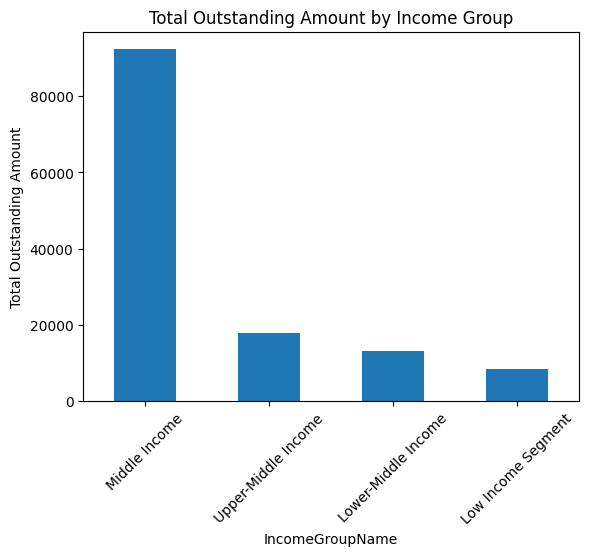

In [88]:
income_exposure["TotalOutstandingAmount"].plot(
    kind="bar",
    title="Total Outstanding Amount by Income Group"
)

plt.ylabel("Total Outstanding Amount")
plt.xticks(rotation=45)
plt.show()


## 👥 8. Exposure by Age Group

👉 WHY: Age segmentation can reveal whether the company has higher exposure in younger, middle-aged, or older customer groups.


In [89]:
age_exposure = df_customer.groupby("AgeGroupName").agg({
    "CustomerID": "count",
    "NumberOfLoans": "sum",
    "AmountOfLoans": "sum",
    "TotalOutstandingAmount": "sum"
}).rename(columns={
    "CustomerID": "CustomerCount"
}).sort_values(by="TotalOutstandingAmount", ascending=False)

age_exposure


,CustomerCount,NumberOfLoans,AmountOfLoans,TotalOutstandingAmount
AgeGroupName,,,,
Mid-Career Adults,3,3,69860.0,64820.0
Early Professionals,5,5,44000.0,36380.0
Mature Professionals,2,2,72000.0,18000.0
Young Adults,3,3,17600.0,12700.0
Seniors,1,1,3150.0,0.0


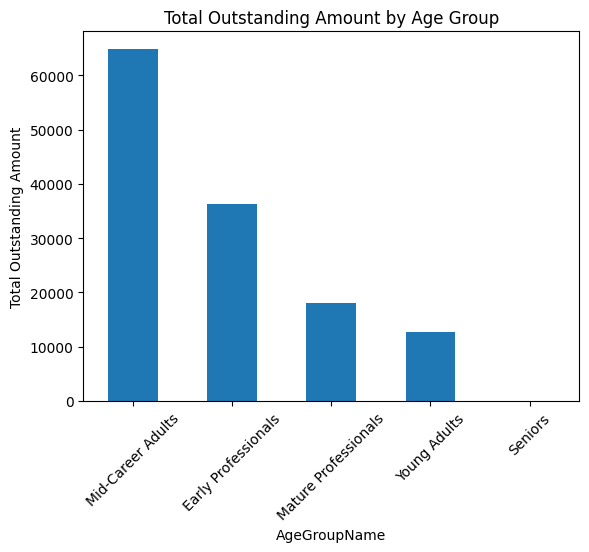

In [90]:
age_exposure["TotalOutstandingAmount"].plot(
    kind="bar",
    title="Total Outstanding Amount by Age Group"
)

plt.ylabel("Total Outstanding Amount")
plt.xticks(rotation=45)
plt.show()


## 🎓 9. Exposure by Education Level

👉 WHY: Education can be used as a socio-demographic dimension for customer segmentation and creditworthiness analysis.


In [91]:
education_exposure = df_customer.groupby("EducationName").agg({
    "CustomerID": "count",
    "NumberOfLoans": "sum",
    "AmountOfLoans": "sum",
    "TotalOutstandingAmount": "sum"
}).rename(columns={
    "CustomerID": "CustomerCount"
}).sort_values(by="TotalOutstandingAmount", ascending=False)

education_exposure


,CustomerCount,NumberOfLoans,AmountOfLoans,TotalOutstandingAmount
EducationName,,,,
Higher,9,9,137440.0,118680.0
Secondary,5,5,69170.0,13220.0


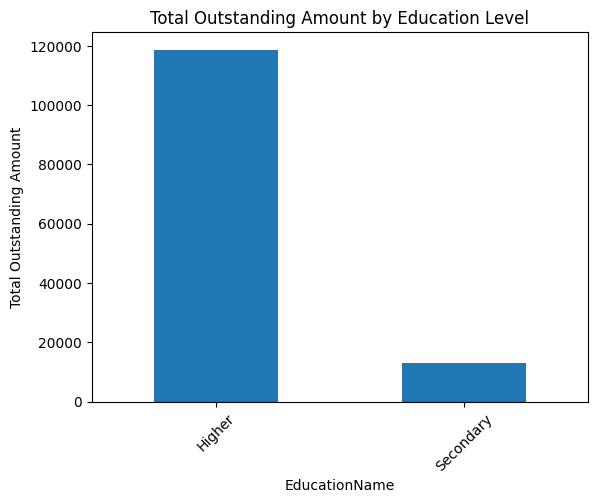

In [92]:
education_exposure["TotalOutstandingAmount"].plot(
    kind="bar",
    title="Total Outstanding Amount by Education Level"
)

plt.ylabel("Total Outstanding Amount")
plt.xticks(rotation=45)
plt.show()


## 💳 10. Load Repayment Behavior / Risk Data

👉 WHY: Customer behavior analysis requires repayment and delinquency indicators.

We use loan risk metrics:
- `AverageDPD` → average days past due
- `MaximumDPD` → maximum delay
- `NPL` → non-performing loan flag
- `AtRisk` → risky loan flag
- `TotalOutstanding` → exposure


In [93]:
risk_query = """
SELECT
    r.DateID,
    r.LoanID,
    r.ProductID,
    p.ProductName,

    r.AverageDPD,
    r.MaximumDPD,
    r.TotalOutstanding,
    r.NPL,
    r.AtRisk

FROM OLAP.FACT_LOAN_RISK r
LEFT JOIN OLAP.DIM_LOANPRODUCT p
    ON r.ProductID = p.ProductID
"""

df_risk = pd.read_sql(risk_query, engine)

df_risk.head()


,DateID,LoanID,ProductID,ProductName,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk
0,20260427,1,40,Student Loan,50.0,92,4200.0,0,0
1,20260427,2,40,Student Loan,59.0,123,3100.0,1,1
2,20260427,3,20,Personal Loan,117.0,158,5300.0,0,1
3,20260427,4,30,Auto Loan,166.0,208,12400.0,1,1
4,20260427,5,10,Mortgage Loan,0.0,0,0.0,0,0


## 🔍 11. Repayment Behavior Overview

👉 WHY: Measure general repayment health using delays and risk flags.


In [94]:
df_risk.agg({
    "LoanID": "count",
    "AverageDPD": "mean",
    "MaximumDPD": "max",
    "TotalOutstanding": "sum",
    "NPL": "mean",
    "AtRisk": "mean"
})


LoanID                  14.000000
AverageDPD              82.785714
MaximumDPD             398.000000
TotalOutstanding    131900.000000
NPL                      0.357143
AtRisk                   0.500000
dtype: float64

### Convert NPL and AtRisk to Percentages

👉 WHY: For binary columns (`0`/`1`), the mean is the percentage of records equal to `1`. 


In [95]:
repayment_summary = pd.DataFrame({
    "Metric": ["NPL Rate (%)", "AtRisk Rate (%)", "Average DPD", "Maximum DPD", "Total Outstanding"],
    "Value": [
        round(df_risk["NPL"].mean() * 100, 2),
        round(df_risk["AtRisk"].mean() * 100, 2),
        round(df_risk["AverageDPD"].mean(), 2),
        df_risk["MaximumDPD"].max(),
        df_risk["TotalOutstanding"].sum()
    ]
})

repayment_summary


,Metric,Value
0,NPL Rate (%),35.71
1,AtRisk Rate (%),50.00
2,Average DPD,82.79
3,Maximum DPD,398.00
4,Total Outstanding,131900.00


## 🚨 12. Risk Category Classification

👉 WHY: Classifying loans makes repayment behavior easier to interpret and communicate.

Business rule:
- `Severe` → NPL = 1
- `Moderate` → AtRisk = 1 but not NPL
- `Low` → not AtRisk and not NPL


In [96]:
df_risk["RiskCategory"] = df_risk.apply(
    lambda row: "Severe" if row["NPL"] == 1 else
                "Moderate" if row["AtRisk"] == 1 else
                "Low",
    axis=1
)

df_risk[["LoanID", "ProductName", "AverageDPD", "MaximumDPD", "TotalOutstanding", "NPL", "AtRisk", "RiskCategory"]].head()


,LoanID,ProductName,AverageDPD,MaximumDPD,TotalOutstanding,NPL,AtRisk,RiskCategory
0,1,Student Loan,50.0,92,4200.0,0,0,Low
1,2,Student Loan,59.0,123,3100.0,1,1,Severe
2,3,Personal Loan,117.0,158,5300.0,0,1,Moderate
3,4,Auto Loan,166.0,208,12400.0,1,1,Severe
4,5,Mortgage Loan,0.0,0,0.0,0,0,Low


In [97]:
risk_category_summary = df_risk.groupby("RiskCategory").agg({
    "LoanID": "count",
    "TotalOutstanding": "sum",
    "AverageDPD": "mean"
}).rename(columns={
    "LoanID": "LoanCount",
    "AverageDPD": "AvgDPD"
}).sort_values(by="TotalOutstanding", ascending=False)

risk_category_summary


,LoanCount,TotalOutstanding,AvgDPD
RiskCategory,,,
Severe,5,113380.0,173.600000
Low,7,9600.0,12.428571
Moderate,2,8920.0,102.000000


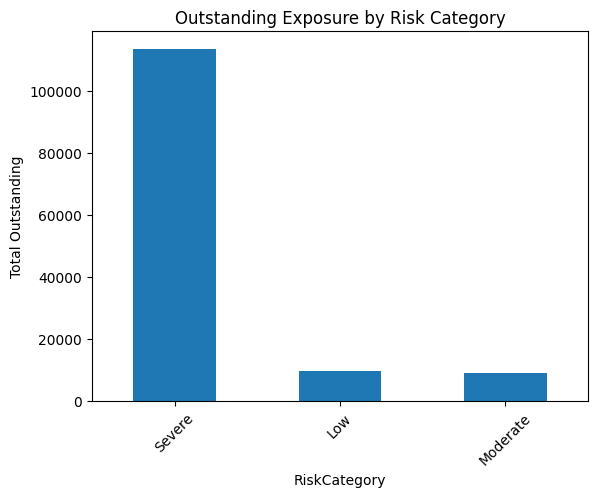

In [98]:
risk_category_summary["TotalOutstanding"].plot(
    kind="bar",
    title="Outstanding Exposure by Risk Category"
)

plt.ylabel("Total Outstanding")
plt.xticks(rotation=45)
plt.show()


## 📊 13. Product Behavior Analysis

👉 WHY: Even in a customer behavior notebook, product-level comparison helps understand where repayment issues are concentrated.


In [99]:
product_behavior = df_risk.groupby("ProductName").agg({
    "LoanID": "count",
    "TotalOutstanding": "sum",
    "NPL": "mean",
    "AtRisk": "mean",
    "AverageDPD": "mean",
    "MaximumDPD": "max"
}).rename(columns={
    "LoanID": "LoanCount",
    "NPL": "NPLRate",
    "AtRisk": "AtRiskRate",
    "AverageDPD": "AvgDPD"
})

product_behavior["NPLRate (%)"] = (product_behavior["NPLRate"] * 100).round(2)
product_behavior["AtRiskRate (%)"] = (product_behavior["AtRiskRate"] * 100).round(2)

product_behavior = product_behavior.drop(columns=["NPLRate", "AtRiskRate"])
product_behavior.sort_values(by="TotalOutstanding", ascending=False)


,LoanCount,TotalOutstanding,AvgDPD,MaximumDPD,NPLRate (%),AtRiskRate (%)
ProductName,,,,,,
Mortgage Loan,2,61200.0,179.000000,398,50.00,50.00
Auto Loan,2,31080.0,154.500000,208,100.00,100.00
Business Loan,1,18000.0,142.000000,214,100.00,100.00
Student Loan,3,12700.0,48.666667,123,33.33,33.33
Personal Loan,6,8920.0,34.000000,158,0.00,33.33


## 🔥 14. Segment Risk Matrix

👉 WHY: A risk matrix helps compare two segmentation dimensions together.

This example compares exposure by `IncomeGroupName` and `AgeGroupName`.


In [100]:
segment_matrix = pd.pivot_table(
    df_customer,
    values="TotalOutstandingAmount",
    index="IncomeGroupName",
    columns="AgeGroupName",
    aggfunc="sum",
    fill_value=0
)

segment_matrix


AgeGroupName,Early Professionals,Mature Professionals,Mid-Career Adults,Seniors,Young Adults
IncomeGroupName,,,,,
Low Income Segment,0.0,0.0,0.0,0.0,8500.0
Lower-Middle Income,5300.0,0.0,3620.0,0.0,4200.0
Middle Income,31080.0,0.0,61200.0,0.0,0.0
Upper-Middle Income,0.0,18000.0,0.0,0.0,0.0


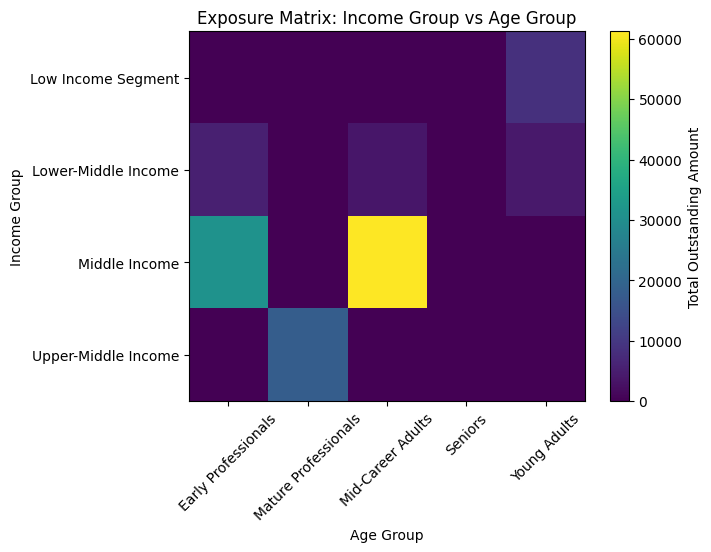

In [101]:
plt.imshow(segment_matrix, aspect="auto")
plt.title("Exposure Matrix: Income Group vs Age Group")
plt.xlabel("Age Group")
plt.ylabel("Income Group")
plt.xticks(range(len(segment_matrix.columns)), segment_matrix.columns, rotation=45)
plt.yticks(range(len(segment_matrix.index)), segment_matrix.index)
plt.colorbar(label="Total Outstanding Amount")
plt.show()


## 🧾 15. Key Findings Template

Use this section after running the notebook and reviewing your real results.

### Customer-Level Analytics
- Identify customers with the largest outstanding exposure.
- These customers should be prioritized for monitoring because they represent higher financial impact.

### Customer Behavior Analysis
- Use DPD, NPL, and AtRisk to understand repayment behavior.
- Severe loans represent the most urgent operational risk.

### Customer Segmentation
- Compare exposure by income, age, and education.
- Segments with higher exposure and higher risk should be monitored more closely.

---

## Tactical Recommendations

Possible recommendations:
- Monitor customers with high outstanding balances.
- Apply stricter review rules for high-risk segments.
- Adjust credit terms for segments showing weaker repayment behavior.
- Use segmentation insights to personalize repayment plans and risk monitoring.

---

## Limitations

- This notebook depends on available OLAP fields and current data volume.
- Customer risk would be stronger if direct customer-to-loan repayment history is available.
- Results should be interpreted carefully when the dataset is small.
